In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

matplotlib.rcParams['pdf.fonttype'] = 42


In [9]:
patient_metadata = pd.read_csv('../../5_figure_MPN_JAK2/data/patient_diagnoses.csv')
patient_metadata['sample'] = patient_metadata['sample'].str.replace('-','')
sample_to_diagnosis = patient_metadata.set_index('sample')['Diagnosis '].to_dict()

### add diagnosis and number to make unique
sample_to_diagnosis['BC003_4plex'] = sample_to_diagnosis['BC003_4plex'] + ' 1'
sample_to_diagnosis['BC002_1'] = sample_to_diagnosis['BC002_1'] + ' 1'
sample_to_diagnosis['BC014_1'] = sample_to_diagnosis['BC014_1'] + ' 1'
sample_to_diagnosis['BC001_1plex'] = sample_to_diagnosis['BC001_1plex'] + ' 2'
sample_to_diagnosis['BC001_4plex'] = sample_to_diagnosis['BC001_4plex'] + ' 2'
sample_to_diagnosis['BC003_1'] = sample_to_diagnosis['BC003_1'] + ' 1'

Index(['monocyte_BC001_1plex', 'monocyte_BC001_4plex', 'monocyte_BC002_1',
       'monocyte_BC003_1', 'monocyte_BC003_4plex', 'monocyte_BC014_1'],
      dtype='object')
Index(['PMF 2', 'postET MF 2', 'PV 1', 'postPV MF 1', 'postET MF 1', 'PMF 1'], dtype='object')
Index(['HSC_BC001_1plex', 'HSC_BC001_4plex', 'HSC_BC003_1', 'HSC_BC003_4plex',
       'HSC_BC014_1'],
      dtype='object')
Index(['PMF 2', 'postET MF 2', 'postPV MF 1', 'postET MF 1', 'PMF 1'], dtype='object')


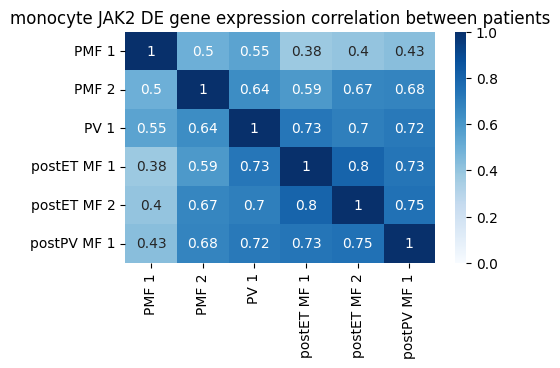

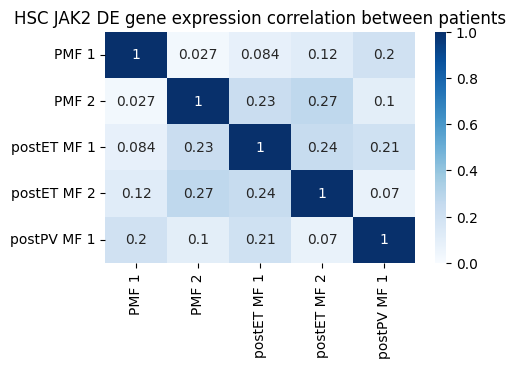

In [10]:
for cell_type in ['monocyte','HSC']:
    DE = pd.read_csv('../../5_figure_MPN_JAK2/output/' + cell_type + '_jak2_de_individual_patients.csv', index_col = 0)
    print(DE.columns)
    print(DE.columns.str.replace(cell_type + '_', '').map(sample_to_diagnosis))
    DE.columns = DE.columns.str.replace(cell_type + '_', '').map(sample_to_diagnosis)
    DE = DE.sort_index(axis=1)

    plt.figure(figsize=(5,3))
    sns.heatmap(DE.corr(), vmin=0, vmax=1, cmap = 'Blues', annot=True)
    plt.title(cell_type + ' JAK2 DE gene expression correlation between patients')

    plt.savefig('../plots/' + cell_type + '_jak2_de_correlation_heatmap.pdf')